Synthetic data set: https://www.kaggle.com/datasets/nudratabbas/global-ads-performance-google-meta-tiktok

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# Phase 1: Creating Database

In [5]:
import sqlite3

In [11]:
global_ads_df = pd.read_csv('data/global_ads_performance_dataset.csv')

print(global_ads_df.columns.tolist())

#Impressions: number of times the ad was shown
#CTR: click-through rate
#CPC: cost per click
#CPA: cost per acquisition
#ROAS: return on ad spend (revenue / spend)

['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']


In [12]:
conn = sqlite3. connect('global_ads.db')

global_ads_df.to_sql('global_ads', conn, if_exists = 'replace', index = False)

print('Database saved!')

Database saved!


# Phase 2: Exploratory Data Analysis & SQL Querying

In [ ]:
query1 = """
    SELECT DISTINCT 
        platform, 
        country, 
        SUM(impressions) AS total_impressions, 
        SUM(clicks) AS total_clicks, 
        SUM(conversions) AS total_conversions
    FROM global_ads
    GROUP BY country, platform
    ORDER BY country, platform
"""

query1_df = pd.read_sql_query(query1, conn)
query1_df['click_rate'] = round((query1_df['total_clicks'] / query1_df['total_impressions']), 4)
query1_df['click_to_conversion_rate'] = round((query1_df['total_conversions'] / query1_df['total_clicks']), 4)

query1_df

,platform,country,total_impressions,total_clicks,total_conversions,click_rate,click_to_conversion_rate
0,Google Ads,Australia,11074095,447654,20914,0.0404,0.0467
1,Meta Ads,Australia,6421987,162572,7677,0.0253,0.0472
2,TikTok Ads,Australia,6305418,350699,17278,0.0556,0.0493
3,Google Ads,Canada,11308339,430478,17995,0.0381,0.0418
4,Meta Ads,Canada,8851252,202200,8943,0.0228,0.0442
5,TikTok Ads,Canada,7241692,402126,19305,0.0555,0.0480
6,Google Ads,Germany,9898258,401337,18063,0.0405,0.0450
7,Meta Ads,Germany,9847695,239088,11254,0.0243,0.0471
8,TikTok Ads,Germany,6372853,354146,15451,0.0556,0.0436
9,Google Ads,India,9119665,330113,14995,0.0362,0.0454


In [78]:
query2 = """
    SELECT
         CASE strftime('%m', date) 
            WHEN '01' THEN 'January'
            WHEN '02' THEN 'February'
            WHEN '03' THEN 'March'
            WHEN '04' THEN 'April'
            WHEN '05' THEN 'May'
            WHEN '06' THEN 'June'
            WHEN '07' THEN 'July'
            WHEN '08' THEN 'August'
            WHEN '09' THEN 'September'
            WHEN '10' THEN 'October'
            WHEN '11' THEN 'November'
            WHEN '12' THEN 'December'
            ELSE NULL
         END AS month, 
         platform, SUM(impressions) AS month_impressions, 
         SUM(clicks) AS month_clicks, 
         SUM(conversions) AS month_conversions
    FROM global_ads
    GROUP BY month, platform
    ORDER BY CASE month
                WHEN 'January' THEN 1
                WHEN 'February' THEN 2
                WHEN 'March' THEN 3
                WHEN 'April' THEN 4
                WHEN 'May' THEN 5
                WHEN 'June' THEN 6
                WHEN 'July' THEN 7
                WHEN 'August' THEN 8
                WHEN 'September' THEN 9
                WHEN 'October' THEN 10
                WHEN 'November' THEN 11
                WHEN 'December' THEN 12
                ELSE NULL
            END, date
"""

query2_df = pd.read_sql_query(query2, conn)
query2_df

,month,platform,month_impressions,month_clicks,month_conversions
0,January,Meta Ads,7463528,186457,8641
1,January,Google Ads,5374750,195369,8970
2,January,TikTok Ads,4137760,230249,10434
3,February,Meta Ads,4625254,123078,5624
4,February,TikTok Ads,4416464,255369,11793
5,February,Google Ads,6348968,259429,11146
6,March,Meta Ads,5761195,120524,5402
7,March,Google Ads,6379805,244800,10733
8,March,TikTok Ads,3230417,173775,8493
9,April,TikTok Ads,4932459,272248,12491


# Phase 3: Data Visualization

In [87]:
# Global dark theme settings
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "monospace"
})

print("Style loaded!")


Style loaded!


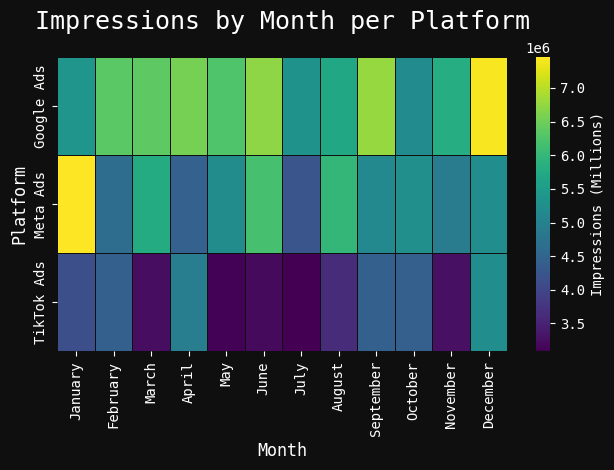

In [88]:
custom_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

heatmap1_pivot = query2_df.pivot_table(
    index = 'platform',
    columns = 'month',
    values = 'month_impressions'
)


sns.heatmap(heatmap1_pivot.reindex(columns=custom_order), 
            cmap = 'viridis', 
            linewidth = 0.5, 
            linecolor = '#0f0f0f', 
            annot = False, 
            cbar_kws = {'label': 'Impressions (Millions)'})

plt.title('Impressions by Month per Platform', fontsize = 18, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

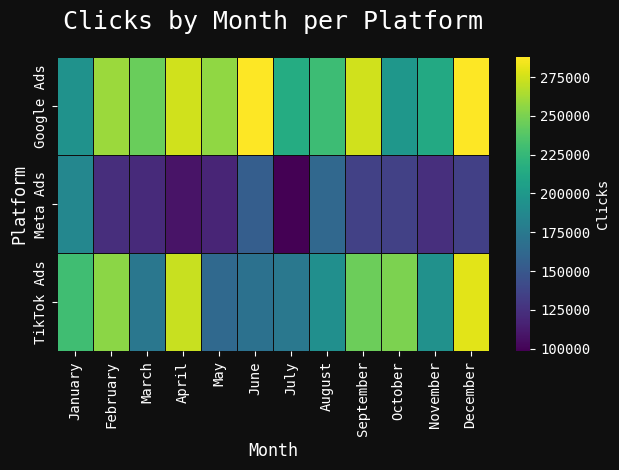

In [89]:
heatmap2_pivot = query2_df.pivot_table(
    index = 'platform',
    columns = 'month',
    values = 'month_clicks'
)


sns.heatmap(heatmap2_pivot.reindex(columns=custom_order), 
            cmap = 'viridis', 
            linewidth = 0.5, 
            linecolor = '#0f0f0f', 
            annot = False, 
            cbar_kws = {'label': 'Clicks'})

plt.title('Clicks by Month per Platform', fontsize = 18, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

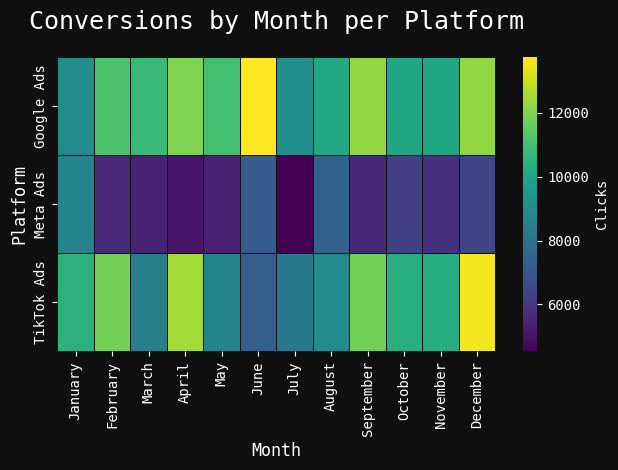

In [90]:
heatmap3_pivot = query2_df.pivot_table(
    index = 'platform',
    columns = 'month',
    values = 'month_conversions'
)


sns.heatmap(heatmap3_pivot.reindex(columns=custom_order), 
            cmap = 'viridis', 
            linewidth = 0.5, 
            linecolor = '#0f0f0f', 
            annot = False, 
            cbar_kws = {'label': 'Clicks'})

plt.title('Conversions by Month per Platform', fontsize = 18, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()